In [ ]:
!pip install -q transformers torch accelerate sentencepiece

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Set up device (use GPU if available in your Colab runtime settings)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load the dedicated Banglish-to-Bangla translation model
model_name = "fms-byte/banglish_to_bangla"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

def transliterate_banglish(text_list):
    print("\n--- Running Transliteration Test ---")

    # Process each sentence through the encoder-decoder layers
    for text in text_list:
        inputs = tokenizer(text, return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_length=128,
                num_beams=4,
                early_stopping=True
            )

        output_script = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

        print(f"Input  (Banglish): {text}")
        print(f"Output (Bangla)  : {output_script}")
        print("-" * 45)

# 3. Define test cases (Feel free to edit these or add your own!)
my_test_sentences = [
    "ami ajke onek khushi mamu!",
    "tumi kothay jaccho ekhon?",
    "bhai amar laptop ta slow hoye gese keno bolto"
]

# Run it!
transliterate_banglish(my_test_sentences)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/992 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]


--- Running Transliteration Test ---
Input  (Banglish): ami ajke onek khushi mamu!
Output (Bangla)  : আমি আজকে অনেক খুশি মামু!
---------------------------------------------
Input  (Banglish): tumi kothay jaccho ekhon?
Output (Bangla)  : তুমি কোথায় যাচ্ছে এখন?
---------------------------------------------
Input  (Banglish): bhai amar laptop ta slow hoye gese keno bolto
Output (Bangla)  : ভাই আমার ল্যাপটপ টা স্লো হয়ে গেছে কেন বলত
---------------------------------------------


In [2]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification
)

class CascadedBanglishEmotionPipeline:
    def __init__(self, device=None):
        # Automatically use GPU (cuda) if you enabled it in Colab's Runtime settings
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        print(f"Initializing pipeline on device: {self.device}")

        # --- STAGE 1: Banglish to Bangla Script Model ---
        self.stage1_model_name = "fms-byte/banglish_to_bangla"
        self.t15n_tokenizer = AutoTokenizer.from_pretrained(self.stage1_model_name)
        self.t15n_model = AutoModelForSeq2SeqLM.from_pretrained(self.stage1_model_name).to(self.device)

        # --- STAGE 2: Native Bangla Emotion Classifier ---
        self.stage2_model_name = "csebuetnlp/banglabert"
        self.emotion_tokenizer = AutoTokenizer.from_pretrained(self.stage2_model_name)

        # We initialize a classification head with 6 labels matching Ekman's universal emotions
        self.emotion_model = AutoModelForSequenceClassification.from_pretrained(
            self.stage2_model_name,
            num_labels=6
        ).to(self.device)

        self.emotion_labels = ["Joy", "Sadness", "Anger", "Disgust", "Fear", "Surprise"]

    def run_stage1_transliterate(self, text: str) -> str:
        """Converts raw phonetic Banglish strings into native standard Bengali script."""
        inputs = self.t15n_tokenizer(text, return_tensors="pt", padding=True).to(self.device)

        with torch.no_grad():
            generated_ids = self.t15n_model.generate(
                **inputs,
                max_length=128,
                num_beams=4,
                early_stopping=True
            )

        bangla_script_text = self.t15n_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        return bangla_script_text

    def run_stage2_classify(self, bangla_text: str) -> dict:
        """Classifies the clean native Bengali script into fine-grained emotion vectors."""
        inputs = self.emotion_tokenizer(bangla_text, return_tensors="pt", padding=True).to(self.device)

        with torch.no_grad():
            outputs = self.emotion_model(**inputs)
            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=-1).squeeze().tolist()

        emotion_scores = {self.emotion_labels[i]: prob for i, prob in enumerate(probabilities)}
        predicted_class_idx = torch.argmax(logits, dim=-1).item()

        return {
            "predicted_emotion": self.emotion_labels[predicted_class_idx],
            "confidence_scores": emotion_scores
        }

    def predict(self, raw_banglish_text: str) -> dict:
        """Executes the full cascaded inference flow."""
        translated_bangla = self.run_stage1_transliterate(raw_banglish_text)
        emotion_results = self.run_stage2_classify(translated_bangla)

        return {
            "raw_input": raw_banglish_text,
            "stage1_transliteration": translated_bangla,
            "stage2_output": emotion_results
        }

In [3]:
# Instantiate the class
pipeline = CascadedBanglishEmotionPipeline()

Initializing pipeline on device: cuda


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
# Feel free to change or add your own Banglish sentences to this list!
sample_texts = [
    "Areeh vaii, valo lagtese!",
    "bhai bondhu ta amay pura bash khawailo re...",
    "Kop mama!! tmi toh pura bazi dita fello"
]

print("--- Running Cascaded Pipeline Inference ---")
for sample in sample_texts:
    result = pipeline.predict(sample)
    print(f"\n[Raw Input]: {result['raw_input']}")
    print(f"[Stage 1 Transliteration]: {result['stage1_transliteration']}")
    print(f"[Stage 2 Predicted Emotion]: {result['stage2_output']['predicted_emotion']}")
    print("-" * 50)

--- Running Cascaded Pipeline Inference ---

[Raw Input]: Areeh vaii, valo lagtese!
[Stage 1 Transliteration]: আরেহ ভাই, ভালো লাগছে!
[Stage 2 Predicted Emotion]: Surprise
--------------------------------------------------

[Raw Input]: bhai bondhu ta amay pura bash khawailo re...
[Stage 1 Transliteration]: ভাই বন্ধু টা আমায় পুরা বাঁশ খাওয়ালো রে...
[Stage 2 Predicted Emotion]: Sadness
--------------------------------------------------

[Raw Input]: Kop mama!! tmi toh pura bazi dita fello
[Stage 1 Transliteration]: কপ মামা!! টিমোই তো পুরা বাসি টাইটা ফেলেল
[Stage 2 Predicted Emotion]: Surprise
--------------------------------------------------


# **The real experiment begins from here!**

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [6]:
import pandas as pd

# Path to the CSV file
csv_file_path = '/content/Emotion.csv'

# Read the CSV file into a pandas DataFrame, specifying the semicolon delimiter
df = pd.read_csv(csv_file_path, sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

,id,text,emotion,lan,domain
0,2275,Hands down. You are good. I mean smart good.,joy,EN,funny_video
1,2283,Your are very good. keep it up,none,EN,funny_video
2,2292,Man!! I will never get used to these videos of...,surprise,EN,funny_video
3,2293,ডিসলাইক দেয়া 32,none,BN,funny_video
4,2298,ব্যাপক বিনোদন।,joy,BN,funny_video


In [7]:
print(f"Shape of the DataFrame: {df.shape}")

Shape of the DataFrame: (2890, 5)


In [8]:
print("Number of null values per column:")
display(df.isnull().sum())

Number of null values per column:


,0
id,0
text,0
emotion,0
lan,0
domain,0


In [9]:
print("Unique emotions:")
display(df['emotion'].unique())

print("Unique languages (lan):")
display(df['lan'].unique())

Unique emotions:


array(['joy', 'none', 'surprise', 'disgust', 'sad', 'fear', 'anger',
       'others'], dtype=object)

Unique languages (lan):


array(['EN', 'BN', 'RN'], dtype=object)

/tmp/ipykernel_527/2067464281.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion', palette='viridis', order=df['emotion'].value_counts().index)


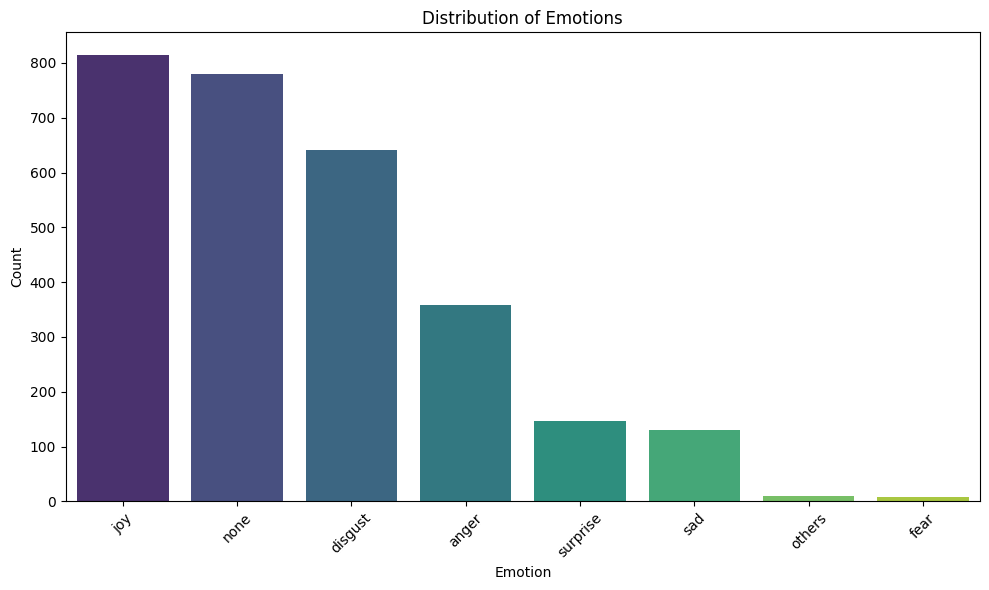

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of 'emotion'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='emotion', palette='viridis', order=df['emotion'].value_counts().index)
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_527/2835061474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='lan', palette='coolwarm', order=df['lan'].value_counts().index)


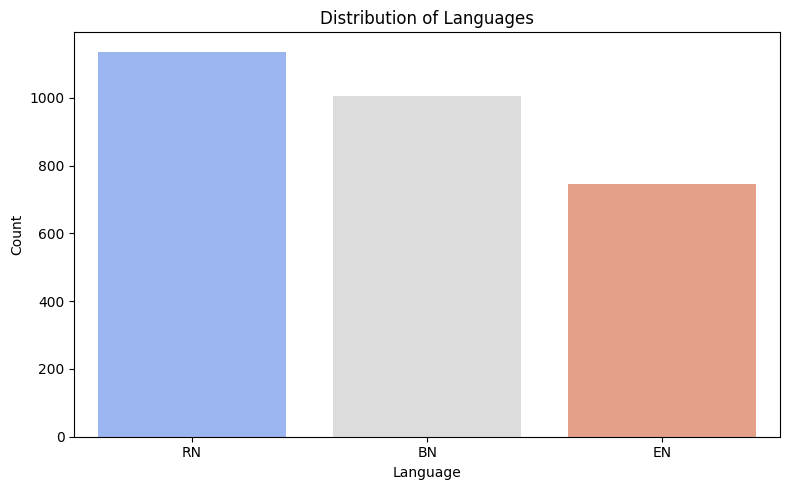

In [11]:
# Distribution of 'lan' (language)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='lan', palette='coolwarm', order=df['lan'].value_counts().index)
plt.title('Distribution of Languages')
plt.xlabel('Language')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# Get the unique classes and their counts from the original 'emotion' column
class_labels = df['emotion'].unique()
class_labels.sort() # Ensure consistent order

# Calculate class weights for the original (imbalanced) dataset
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=df['emotion']
)

# Convert to a dictionary for easier lookup (optional, but good for understanding)
weights_dict = dict(zip(class_labels, class_weights))
print("Calculated Class Weights (for original, imbalanced dataset):")
for emotion, weight in weights_dict.items():
    print(f"  {emotion}: {weight:.4f}")

# Convert to a PyTorch tensor, as needed by nn.CrossEntropyLoss
# Ensure the order of weights matches the order of class IDs in your model's output
# For demonstration, let's assume 'anger' corresponds to index 0, 'disgust' to 1, etc.
# You would map your actual emotion labels to their corresponding indices.

# This is a critical step: ensure your model's output indices match these weights.
# For example, if 'anger' is model output 0, 'disgust' output 1, etc.
# Let's create a mapping based on our sorted class_labels
label_to_idx = {label: i for i, label in enumerate(class_labels)}

# Create a weights tensor in the correct order for your loss function
weights_tensor = torch.tensor([weights_dict[label] for label in class_labels], dtype=torch.float32)

print(f"\nPyTorch Class Weights Tensor: {weights_tensor}")
print(f"Mapping of Labels to Indices: {label_to_idx}")

Calculated Class Weights (for original, imbalanced dataset):
  anger: 1.0063
  disgust: 0.5636
  fear: 45.1562
  joy: 0.4433
  none: 0.4631
  others: 40.1389
  sad: 2.7576
  surprise: 2.4575

PyTorch Class Weights Tensor: tensor([ 1.0063,  0.5636, 45.1562,  0.4433,  0.4631, 40.1389,  2.7576,  2.4575])
Mapping of Labels to Indices: {'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'none': 4, 'others': 5, 'sad': 6, 'surprise': 7}


### How to use `weights_tensor` with a PyTorch Loss Function

When training a model with PyTorch, you would pass this `weights_tensor` to your loss function, typically `nn.CrossEntropyLoss`.

```python
import torch.nn as nn

# Initialize your loss function with the calculated class weights
# Make sure the weights are on the same device as your model and data
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

# During your training loop, after getting model predictions and true labels:
# predictions = model(inputs)  # Raw logits from your model, shape (batch_size, num_classes)
# true_labels = labels         # True integer labels, shape (batch_size)

# loss = loss_fn(predictions, true_labels)
# loss.backward()
# optimizer.step()
```

This `weight` argument in `nn.CrossEntropyLoss` applies a penalty to each class, meaning misclassifying a minority class sample will contribute more to the total loss than misclassifying a majority class sample. This encourages the model to learn better representations for the underrepresented classes without altering the dataset itself.

In [13]:
df = df[['text', 'emotion', 'lan']]
display(df.head())

,text,emotion,lan
0,Hands down. You are good. I mean smart good.,joy,EN
1,Your are very good. keep it up,none,EN
2,Man!! I will never get used to these videos of...,surprise,EN
3,ডিসলাইক দেয়া 32,none,BN
4,ব্যাপক বিনোদন।,joy,BN


### Cleaning Bengali ('bn') Text Data

For Bengali text, we will perform the following cleaning steps:

1.  **Remove Punctuation**: Punctuation marks are generally not indicative of emotion and can add noise.
2.  **Remove Numbers**: Numbers typically don't carry emotional meaning.
3.  **Remove Extra Whitespaces**: Standardize spacing.

We will apply these steps only to the rows where the `lan` column is 'BN', leaving 'EN' and 'RN' texts as they are.

In [ ]:
import re
import string

def clean_bengali_text(text):
    # 1. Remove punctuation (including Bengali punctuation)
    text = re.sub(r'[\!"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~]', '', text) # ASCII punctuation
    text = re.sub(r'[—‘’“”ঃ।॥]', '', text) # Common Bengali punctuation

    # 2. Remove numbers (both Western and Bengali digits)
    text = re.sub(r'\d+', '', text) # Western digits
    text = re.sub(r'[০১২৩৪৫৬৭৮৯]', '', text) # Bengali digits

    # 3. Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning only to 'BN' language texts
df.loc[df['lan'] == 'BN', 'text'] = df.loc[df['lan'] == 'BN', 'text'].apply(clean_bengali_text)

print("Sample of cleaned Bengali text data:")
display(df[df['lan'] == 'BN'].head())

Sample of cleaned Bengali text data:


,text,emotion,lan
3,ডিসলাইক দেয়া,none,BN
4,ব্যাপক বিনোদন,joy,BN
8,মন খারাপ থাকলেই ঢুকে পরি আপনার চ্যানেলে,none,BN
13,Taslima Akter কন্টেন্ট ক্রিয়েটর রা এক একটা প্র...,disgust,BN
14,জাতি জানতে চায়,none,BN


### Setting up Transformer Models for Emotion Classification

We'll now prepare the transformer models you requested. For each model, we'll load its specific tokenizer and a `ForSequenceClassification` head, which is suitable for tasks like emotion classification.

Recall the `label_to_idx` and `weights_tensor` we computed earlier. These will be crucial during the training phase to map our categorical emotion labels to numerical IDs and to handle class imbalance, especially when working with models like these.

In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Ensure we're using a GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define the number of unique emotion labels (from our `class_labels` or `label_to_idx`)
num_labels = len(label_to_idx) # Assuming label_to_idx was defined earlier

Using device: cuda


#### 1. BanglaBERT

*   **Model**: `csebuetnlp/banglabert`
*   **Description**: A BERT-like model pre-trained specifically on a large Bengali corpus. It's highly effective for tasks involving the Bengali language due to its specialized pre-training. Ideal for the 'BN' data.


In [18]:
# Load BanglaBERT Tokenizer and Model
banglabert_model_name = "csebuetnlp/banglabert"
banglabert_tokenizer = AutoTokenizer.from_pretrained(banglabert_model_name)
banglabert_model = AutoModelForSequenceClassification.from_pretrained(banglabert_model_name, num_labels=num_labels).to(device)

print(f"Loaded BanglaBERT model: {banglabert_model_name}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded BanglaBERT model: csebuetnlp/banglabert


#### 2. Multilingual BERT (mBERT)

*   **Model**: `bert-base-multilingual-cased`
*   **Description**: A BERT model pre-trained on a large amount of text in 104 languages. It's a good choice if you plan to train on both Bengali and English data, as it can handle multiple languages within a single model. Useful for 'BN' and 'EN' data.


In [19]:
# Load mBERT Tokenizer and Model
mbert_model_name = "bert-base-multilingual-cased"
mbert_tokenizer = AutoTokenizer.from_pretrained(mbert_model_name)
mbert_model = AutoModelForSequenceClassification.from_pretrained(mbert_model_name, num_labels=num_labels).to(device)

print(f"Loaded mBERT model: {mbert_model_name}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded mBERT model: bert-base-multilingual-cased


#### 3. DistilBERT

*   **Model**: `distilbert-base-uncased` (or `distilbert-base-multilingual-cased` if you prefer a multilingual version of DistilBERT)
*   **Description**: A distilled version of BERT, meaning it's smaller, faster, and lighter while retaining much of BERT's performance. It's a great option when computational resources are limited or when faster inference is required. We'll use the uncased English version for now, which would be suitable for 'EN' data.


In [20]:
# Load DistilBERT Tokenizer and Model
distilbert_model_name = "distilbert-base-uncased"
distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_model_name)
distilbert_model = AutoModelForSequenceClassification.from_pretrained(distilbert_model_name, num_labels=num_labels).to(device)

print(f"Loaded DistilBERT model: {distilbert_model_name}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded DistilBERT model: distilbert-base-uncased


Now that the models are loaded, the next steps would typically involve:

1.  **Preprocessing your dataset**: Tokenizing your 'text' data using the respective tokenizer for each model, and converting your 'emotion' labels to numerical IDs using `label_to_idx`.
2.  **Creating PyTorch Datasets and DataLoaders**.
3.  **Training**: Fine-tuning each model on your prepared dataset, using the `weights_tensor` with `nn.CrossEntropyLoss` to handle class imbalance.
4.  **Evaluation**: Assessing the performance of each model on a validation/test set.

### Preparing Bengali (BN) Data for BanglaBERT

We will now filter our dataset to include only Bengali ('BN') text, preprocess it for BanglaBERT, and then create PyTorch Dataset and DataLoader objects. We'll use the `banglabert_tokenizer` and the `label_to_idx` mapping for this.

In [ ]:
# Filter the DataFrame for Bengali (BN) data only
df_bn = df[df['lan'] == 'BN'].copy()

# Tokenize the 'text' column using banglabert_tokenizer
# We'll use truncation and padding to handle varying text lengths
# The outputs will be PyTorch tensors

# Ensure `banglabert_tokenizer` is available from previous steps
if 'banglabert_tokenizer' not in locals():
    from transformers import AutoTokenizer
    banglabert_tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")

# Tokenize texts
tokenized_data = banglabert_tokenizer(list(df_bn['text'].values),
                                      truncation=True,
                                      padding='max_length',
                                      max_length=128,
                                      return_tensors='pt')

# Convert emotion labels to numerical IDs
# Ensure `label_to_idx` is available from previous steps
if 'label_to_idx' not in locals():
    print("Error: label_to_idx not found. Please ensure previous steps ran correctly.")
    # Fallback or raise error, depending on desired robustness
    # For this example, we'll assume it exists or will be created.
    class_labels = sorted(df['emotion'].unique())
    label_to_idx = {label: i for i, label in enumerate(class_labels)}

labels = torch.tensor([label_to_idx[emotion] for emotion in df_bn['emotion'].values])

print(f"Tokenized data input_ids shape: {tokenized_data['input_ids'].shape}")
print(f"Labels shape: {labels.shape}")

Tokenized data input_ids shape: torch.Size([1006, 128])
Labels shape: torch.Size([1006])


### Create PyTorch Dataset and DataLoader

We'll create a custom PyTorch `Dataset` class to handle our tokenized inputs and labels, and then use `DataLoader` for efficient batching during training.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx].clone().detach()
        return item

    def __len__(self):
        return len(self.labels)

# Create the dataset
bn_dataset = EmotionDataset(tokenized_data, labels)

# Create a DataLoader
batch_size = 16 # You can adjust this batch size
bn_dataloader = DataLoader(bn_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of batches in DataLoader: {len(bn_dataloader)}")
print(f"Sample batch from DataLoader (input_ids shape): {next(iter(bn_dataloader))['input_ids'].shape}")

Number of batches in DataLoader: 63
Sample batch from DataLoader (input_ids shape): torch.Size([16, 128])


### Training and Evaluation with BanglaBERT

Now that the data is prepared, here's an outline for how you would train and evaluate the `banglabert_model`:

1.  **Define Optimizer and Learning Rate Scheduler**: Set up `torch.optim.AdamW` and optionally a learning rate scheduler.
2.  **Training Loop**: Iterate through epochs and batches from `bn_dataloader`.
    *   Move inputs and labels to the `device` (GPU).
    *   Perform a forward pass with `banglabert_model`.
    *   Calculate loss using `nn.CrossEntropyLoss` with `weights_tensor`.
    *   Perform backward pass (`loss.backward()`) and optimization step (`optimizer.step()`).
    *   Clear gradients (`optimizer.zero_grad()`).
3.  **Evaluation Loop**: Periodically evaluate the model on a separate validation set (you would split `df_bn` into train/validation first).
    *   Use `model.eval()` and `torch.no_grad()`.
    *   Calculate metrics like accuracy, precision, recall, F1-score for each emotion.

Here's a conceptual code snippet for the training setup:

In [ ]:
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

# Assuming 'banglabert_model' and 'device' are already defined
# and 'weights_tensor' is available and moved to the correct device
if 'weights_tensor' not in locals() or not isinstance(weights_tensor, torch.Tensor):
    print("Error: weights_tensor not found or not a tensor. Please ensure previous steps ran correctly.")
    # For demonstration, creating a dummy if not found
    weights_tensor = torch.ones(num_labels)

loss_fn = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

optimizer = torch.optim.AdamW(banglabert_model.parameters(), lr=2e-5)

epochs = 5 # Example number of epochs
total_steps = len(bn_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

print("Training setup complete. You can now implement the training loop using 'bn_dataloader', 'banglabert_model', 'loss_fn', 'optimizer', and 'scheduler'.")

Training setup complete. You can now implement the training loop using 'bn_dataloader', 'banglabert_model', 'loss_fn', 'optimizer', and 'scheduler'.


### Splitting Data into Training and Validation Sets

Before training, it's crucial to split our `bn_dataset` into training and validation sets to monitor performance on unseen data and prevent overfitting.

In [ ]:
from torch.utils.data import random_split

# Define the split ratios
train_size = int(0.8 * len(bn_dataset))
val_size = len(bn_dataset) - train_size

# Split the dataset
train_dataset, val_dataset = random_split(bn_dataset, [train_size, val_size])

# Create DataLoaders for training and validation sets
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Training batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")

Training samples: 804
Validation samples: 202
Training batches: 51
Validation batches: 13


### Implementing the Training Loop

Now we'll implement the actual training loop for BanglaBERT using the `train_dataloader` and our defined `loss_fn`, `optimizer`, and `scheduler`.

In [ ]:
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score

# Training Loop
banglabert_model.zero_grad()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    banglabert_model.train() # Set model to training mode
    total_train_loss = 0

    for batch in tqdm(train_dataloader, desc="Training"): # Wrap dataloader with tqdm for progress bar
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = banglabert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(banglabert_model.parameters(), 1.0) # Clip gradients to prevent exploding gradients
        optimizer.step()
        scheduler.step()
        banglabert_model.zero_grad()

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"  Average training loss: {avg_train_loss:.4f}")

    # Evaluation after each epoch
    banglabert_model.eval() # Set model to evaluation mode
    total_eval_accuracy = 0
    total_eval_loss = 0
    predictions = []
    true_labels = []

    for batch in tqdm(val_dataloader, desc="Evaluating"): # Wrap dataloader with tqdm
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad(): # No gradient calculations during evaluation
            outputs = banglabert_model(input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_eval_loss += loss.item()
        logits = outputs.logits

        preds = torch.argmax(logits, dim=-1).flatten()

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

    avg_eval_loss = total_eval_loss / len(val_dataloader)
    eval_accuracy = accuracy_score(true_labels, predictions)

    print(f"  Validation loss: {avg_eval_loss:.4f}")
    print(f"  Validation Accuracy: {eval_accuracy:.4f}")

    # Generate classification report for detailed metrics
    # Ensure inverse mapping from index to label exists for report
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]
    print("\n  Classification Report:")
    print(classification_report(true_labels, predictions, labels=list(range(num_labels)), target_names=target_names))

print("\nTraining complete!")


Epoch 1/5


Training:   0%|          | 0/51 [00:00<?, ?it/s]

  Average training loss: 1.2007


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  Validation loss: 1.0965
  Validation Accuracy: 0.6287

  Classification Report:
              precision    recall  f1-score   support

       anger       0.61      0.66      0.63        47
     disgust       0.47      0.64      0.54        53
        fear       0.00      0.00      0.00         1
         joy       0.79      0.75      0.77        36
        none       0.78      0.71      0.74        49
      others       0.00      0.00      0.00         0
         sad       0.00      0.00      0.00         9
    surprise       0.00      0.00      0.00         7

    accuracy                           0.63       202
   macro avg       0.33      0.35      0.34       202
weighted avg       0.60      0.63      0.61       202


Epoch 2/5


...

Training:   0%|          | 0/51 [00:00<?, ?it/s]

  Average training loss: 0.6634


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  Validation loss: 1.0419
  Validation Accuracy: 0.6485

  Classification Report:
              precision    recall  f1-score   support

       anger       0.66      0.57      0.61        47
     disgust       0.49      0.68      0.57        53
        fear       0.00      0.00      0.00         1
         joy       0.79      0.75      0.77        36
        none       0.79      0.84      0.81        49
      others       0.00      0.00      0.00         0
         sad       0.00      0.00      0.00         9
    surprise       0.00      0.00      0.00         7

    accuracy                           0.65       202
   macro avg       0.34      0.36      0.35       202
weighted avg       0.61      0.65      0.63       202


Training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
print(f"Final Validation Accuracy: {eval_accuracy:.4f}")

Final Validation Accuracy: 0.6485


### Preparing Data for mBERT (Multilingual BERT)

In [ ]:
# Filter the DataFrame for Bengali (BN) data for mBERT
df_mbert = df[df['lan'].isin(['BN'])].copy()

# Tokenize the 'text' column using mbert_tokenizer
tokenized_data_mbert = mbert_tokenizer(
    list(df_mbert['text'].values),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

# Convert emotion labels to numerical IDs
labels_mbert = torch.tensor([label_to_idx[emotion] for emotion in df_mbert['emotion'].values])

# Create the dataset
mbert_dataset = EmotionDataset(tokenized_data_mbert, labels_mbert)

print(f"mBERT Tokenized data input_ids shape: {tokenized_data_mbert['input_ids'].shape}")
print(f"mBERT Labels shape: {labels_mbert.shape}")

mBERT Tokenized data input_ids shape: torch.Size([1006, 128])
mBERT Labels shape: torch.Size([1006])


In [ ]:
from torch.utils.data import random_split

# Define the split ratios
train_size_mbert = int(0.8 * len(mbert_dataset))
val_size_mbert = len(mbert_dataset) - train_size_mbert

# Split the dataset
train_dataset_mbert, val_dataset_mbert = random_split(mbert_dataset, [train_size_mbert, val_size_mbert])

# Create DataLoaders for training and validation sets
train_dataloader_mbert = DataLoader(train_dataset_mbert, batch_size=batch_size, shuffle=True)
val_dataloader_mbert = DataLoader(val_dataset_mbert, batch_size=batch_size, shuffle=False)

print(f"mBERT Training samples: {len(train_dataset_mbert)}")
print(f"mBERT Validation samples: {len(val_dataset_mbert)}")
print(f"mBERT Training batches: {len(train_dataloader_mbert)}")
print(f"mBERT Validation batches: {len(val_dataloader_mbert)}")

mBERT Training samples: 804
mBERT Validation samples: 202
mBERT Training batches: 51
mBERT Validation batches: 13


In [ ]:
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

loss_fn_mbert = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

optimizer_mbert = torch.optim.AdamW(mbert_model.parameters(), lr=2e-5)

total_steps_mbert = len(train_dataloader_mbert) * epochs
scheduler_mbert = get_linear_schedule_with_warmup(optimizer_mbert, num_warmup_steps=0, num_training_steps=total_steps_mbert)

print("mBERT Training setup complete.")

mBERT Training setup complete.


### Training and Evaluation for mBERT

In [ ]:
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score

# Training Loop for mBERT
mbert_model.zero_grad()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs} (mBERT)")
    mbert_model.train() # Set model to training mode
    total_train_loss_mbert = 0

    for batch in tqdm(train_dataloader_mbert, desc="mBERT Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = mbert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss_mbert += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(mbert_model.parameters(), 1.0)
        optimizer_mbert.step()
        scheduler_mbert.step()
        mbert_model.zero_grad()

    avg_train_loss_mbert = total_train_loss_mbert / len(train_dataloader_mbert)
    print(f"  mBERT Average training loss: {avg_train_loss_mbert:.4f}")

    # Evaluation after each epoch
    mbert_model.eval() # Set model to evaluation mode
    total_eval_accuracy_mbert = 0
    total_eval_loss_mbert = 0
    predictions_mbert = []
    true_labels_mbert = []

    for batch in tqdm(val_dataloader_mbert, desc="mBERT Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = mbert_model(input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_eval_loss_mbert += loss.item()
        logits = outputs.logits

        preds = torch.argmax(logits, dim=-1).flatten()

        predictions_mbert.extend(preds.cpu().numpy())
        true_labels_mbert.extend(labels.cpu().numpy())

    avg_eval_loss_mbert = total_eval_loss_mbert / len(val_dataloader_mbert)
    eval_accuracy_mbert = accuracy_score(true_labels_mbert, predictions_mbert)

    print(f"  mBERT Validation loss: {avg_eval_loss_mbert:.4f}")
    print(f"  mBERT Validation Accuracy: {eval_accuracy_mbert:.4f}")

    idx_to_label = {v: k for k, v in label_to_idx.items()}
    target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]
    print("\n  mBERT Classification Report:")
    print(classification_report(true_labels_mbert, predictions_mbert, labels=list(range(num_labels)), target_names=target_names))

print("\nmBERT Training complete!")


Epoch 1/5 (mBERT)


mBERT Training:   0%|          | 0/51 [00:00<?, ?it/s]

  mBERT Average training loss: 0.9276


mBERT Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  mBERT Validation loss: 1.4604
  mBERT Validation Accuracy: 0.4851

  mBERT Classification Report:
              precision    recall  f1-score   support

       anger       0.61      0.53      0.57        47
     disgust       0.46      0.56      0.50        61
        fear       0.00      0.00      0.00         0
         joy       0.56      0.59      0.58        37
        none       0.36      0.47      0.41        34
      others       0.00      0.00      0.00         0
         sad       0.33      0.12      0.18         8
    surprise       0.00      0.00      0.00        15

    accuracy                           0.49       202
   macro avg       0.29      0.28      0.28       202
weighted avg       0.46      0.49      0.47       202


Epoch 2/5 (mBERT)


...

mBERT Training:   0%|          | 0/51 [00:00<?, ?it/s]

  mBERT Average training loss: 0.9264


mBERT Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  mBERT Validation loss: 1.4604
  mBERT Validation Accuracy: 0.4851

  mBERT Classification Report:
              precision    recall  f1-score   support

       anger       0.61      0.53      0.57        47
     disgust       0.46      0.56      0.50        61
        fear       0.00      0.00      0.00         0
         joy       0.56      0.59      0.58        37
        none       0.36      0.47      0.41        34
      others       0.00      0.00      0.00         0
         sad       0.33      0.12      0.18         8
    surprise       0.00      0.00      0.00        15

    accuracy                           0.49       202
   macro avg       0.29      0.28      0.28       202
weighted avg       0.46      0.49      0.47       202


mBERT Training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
print(f"Final mBERT Validation Accuracy: {eval_accuracy_mbert:.4f}")

Final mBERT Validation Accuracy: 0.4851


### Preparing Data for DistilBERT

In [ ]:
# Filter the DataFrame for English (EN) data only for DistilBERT
df_distilbert = df[df['lan'] == 'BN'].copy()

# Tokenize the 'text' column using distilbert_tokenizer
tokenized_data_distilbert = distilbert_tokenizer(
    list(df_distilbert['text'].values),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

# Convert emotion labels to numerical IDs
labels_distilbert = torch.tensor([label_to_idx[emotion] for emotion in df_distilbert['emotion'].values])

# Create the dataset
distilbert_dataset = EmotionDataset(tokenized_data_distilbert, labels_distilbert)

print(f"DistilBERT Tokenized data input_ids shape: {tokenized_data_distilbert['input_ids'].shape}")
print(f"DistilBERT Labels shape: {labels_distilbert.shape}")

DistilBERT Tokenized data input_ids shape: torch.Size([1006, 128])
DistilBERT Labels shape: torch.Size([1006])


In [ ]:
from torch.utils.data import random_split

# Define the split ratios
train_size_distilbert = int(0.8 * len(distilbert_dataset))
val_size_distilbert = len(distilbert_dataset) - train_size_distilbert

# Split the dataset
train_dataset_distilbert, val_dataset_distilbert = random_split(distilbert_dataset, [train_size_distilbert, val_size_distilbert])

# Create DataLoaders for training and validation sets
train_dataloader_distilbert = DataLoader(train_dataset_distilbert, batch_size=batch_size, shuffle=True)
val_dataloader_distilbert = DataLoader(val_dataset_distilbert, batch_size=batch_size, shuffle=False)

print(f"DistilBERT Training samples: {len(train_dataset_distilbert)}")
print(f"DistilBERT Validation samples: {len(val_dataset_distilbert)}")
print(f"DistilBERT Training batches: {len(train_dataloader_distilbert)}")
print(f"DistilBERT Validation batches: {len(val_dataloader_distilbert)}")

DistilBERT Training samples: 804
DistilBERT Validation samples: 202
DistilBERT Training batches: 51
DistilBERT Validation batches: 13


In [ ]:
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

loss_fn_distilbert = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

optimizer_distilbert = torch.optim.AdamW(distilbert_model.parameters(), lr=2e-5)

total_steps_distilbert = len(train_dataloader_distilbert) * epochs
scheduler_distilbert = get_linear_schedule_with_warmup(optimizer_distilbert, num_warmup_steps=0, num_training_steps=total_steps_distilbert)

print("DistilBERT Training setup complete.")

DistilBERT Training setup complete.


### Training and Evaluation for DistilBERT

In [ ]:
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score

# Training Loop for DistilBERT
distilbert_model.zero_grad()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs} (DistilBERT)")
    distilbert_model.train() # Set model to training mode
    total_train_loss_distilbert = 0

    for batch in tqdm(train_dataloader_distilbert, desc="DistilBERT Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = distilbert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss_distilbert += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(distilbert_model.parameters(), 1.0)
        optimizer_distilbert.step()
        scheduler_distilbert.step()
        distilbert_model.zero_grad()

    avg_train_loss_distilbert = total_train_loss_distilbert / len(train_dataloader_distilbert)
    print(f"  DistilBERT Average training loss: {avg_train_loss_distilbert:.4f}")

    # Evaluation after each epoch
    distilbert_model.eval() # Set model to evaluation mode
    total_eval_accuracy_distilbert = 0
    total_eval_loss_distilbert = 0
    predictions_distilbert = []
    true_labels_distilbert = []

    for batch in tqdm(val_dataloader_distilbert, desc="DistilBERT Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = distilbert_model(input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_eval_loss_distilbert += loss.item()
        logits = outputs.logits

        preds = torch.argmax(logits, dim=-1).flatten()

        predictions_distilbert.extend(preds.cpu().numpy())
        true_labels_distilbert.extend(labels.cpu().numpy())

    avg_eval_loss_distilbert = total_eval_loss_distilbert / len(val_dataloader_distilbert)
    eval_accuracy_distilbert = accuracy_score(true_labels_distilbert, predictions_distilbert)

    print(f"  DistilBERT Validation loss: {avg_eval_loss_distilbert:.4f}")
    print(f"  DistilBERT Validation Accuracy: {eval_accuracy_distilbert:.4f}")

    idx_to_label = {v: k for k, v in label_to_idx.items()}
    target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]
    print("\n  DistilBERT Classification Report:")
    print(classification_report(true_labels_distilbert, predictions_distilbert, labels=list(range(num_labels)), target_names=target_names))

print("\nDistilBERT Training complete!")


Epoch 1/5 (DistilBERT)


DistilBERT Training:   0%|          | 0/51 [00:00<?, ?it/s]

  DistilBERT Average training loss: 1.5091


DistilBERT Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  DistilBERT Validation loss: 1.5564
  DistilBERT Validation Accuracy: 0.4059

  DistilBERT Classification Report:
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        37
     disgust       0.38      0.81      0.52        59
        fear       0.00      0.00      0.00         0
         joy       0.43      0.51      0.46        45
        none       0.50      0.28      0.35        40
      others       0.00      0.00      0.00         0
         sad       0.00      0.00      0.00         7
    surprise       0.00      0.00      0.00        14

    accuracy                           0.41       202
   macro avg       0.16      0.20      0.17       202
weighted avg       0.31      0.41      0.33       202


Epoch 2/5 (DistilBERT)


...

DistilBERT Training:   0%|          | 0/51 [00:00<?, ?it/s]

  DistilBERT Average training loss: 1.4995


DistilBERT Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

  DistilBERT Validation loss: 1.5564
  DistilBERT Validation Accuracy: 0.4059

  DistilBERT Classification Report:
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        37
     disgust       0.38      0.81      0.52        59
        fear       0.00      0.00      0.00         0
         joy       0.43      0.51      0.46        45
        none       0.50      0.28      0.35        40
      others       0.00      0.00      0.00         0
         sad       0.00      0.00      0.00         7
    surprise       0.00      0.00      0.00        14

    accuracy                           0.41       202
   macro avg       0.16      0.20      0.17       202
weighted avg       0.31      0.41      0.33       202


DistilBERT Training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
print(f"Final DistilBERT Validation Accuracy: {eval_accuracy_distilbert:.4f}")

Final DistilBERT Validation Accuracy: 0.4059


In [ ]:
import pandas as pd

# Create a dictionary to store the accuracies
accuracies = {
    'Model': ['BanglaBERT', 'mBERT', 'DistilBERT'],
    'Validation Accuracy': [eval_accuracy, eval_accuracy_mbert, eval_accuracy_distilbert]
}

# Create a DataFrame from the dictionary
accuracy_df = pd.DataFrame(accuracies)

# Sort by accuracy in descending order for easy comparison
accuracy_df = accuracy_df.sort_values(by='Validation Accuracy', ascending=False).reset_index(drop=True)

print("\n--- Model Validation Accuracy Comparison ---")
display(accuracy_df)
print("------------------------------------------")


--- Model Validation Accuracy Comparison ---


,Model,Validation Accuracy
0,BanglaBERT,0.648515
1,mBERT,0.485149
2,DistilBERT,0.405941


------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

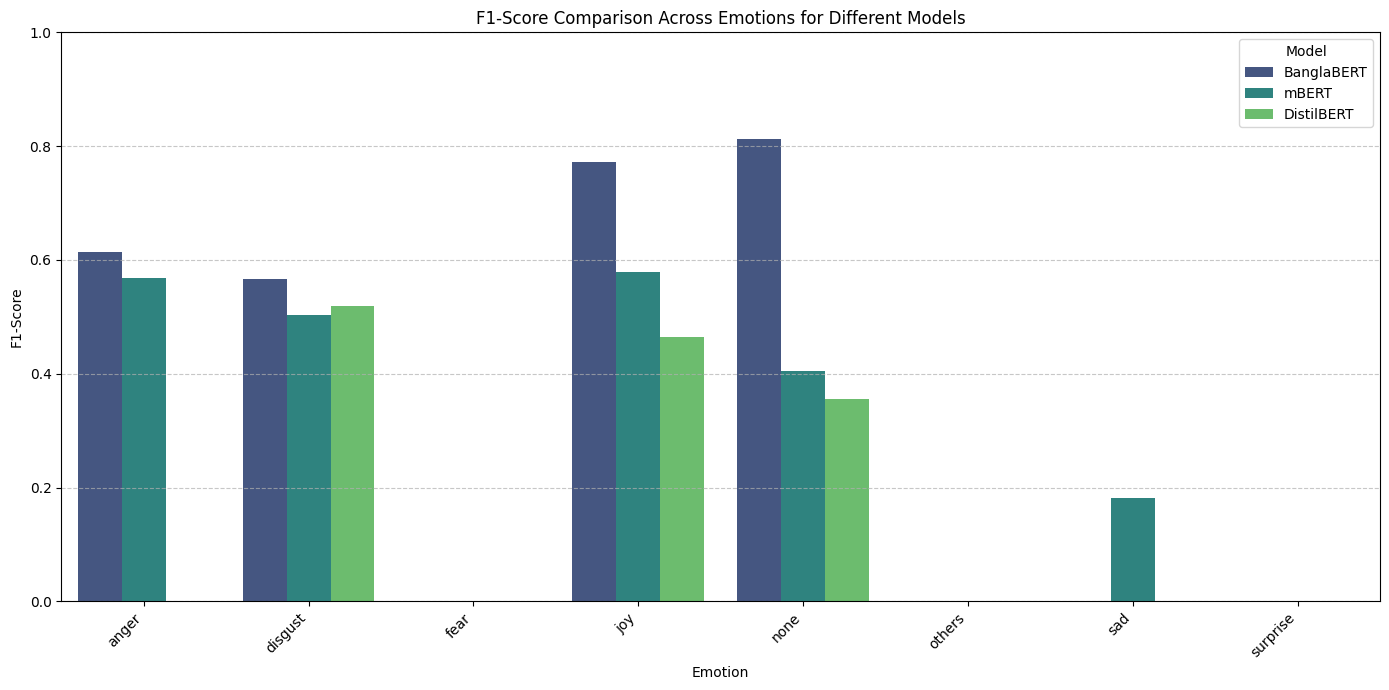

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Get classification reports (assuming true_labels and predictions for each model are available)
report_banglabert = classification_report(true_labels, predictions, labels=list(range(num_labels)), target_names=target_names, output_dict=True)
report_mbert = classification_report(true_labels_mbert, predictions_mbert, labels=list(range(num_labels)), target_names=target_names, output_dict=True)
report_distilbert = classification_report(true_labels_distilbert, predictions_distilbert, labels=list(range(num_labels)), target_names=target_names, output_dict=True)

# Extract F1-scores for each emotion from the reports
def extract_f1_scores(report, model_name):
    f1_scores = []
    for label in target_names:
        # Handle cases where a label might not be in the report (e.g., if support is 0)
        if label in report and 'f1-score' in report[label]:
            f1_scores.append({'Emotion': label, 'Model': model_name, 'F1-Score': report[label]['f1-score']})
        else:
            f1_scores.append({'Emotion': label, 'Model': model_name, 'F1-Score': 0.0}) # Assign 0 if not present or no support
    return f1_scores

f1_scores_banglabert = extract_f1_scores(report_banglabert, 'BanglaBERT')
f1_scores_mbert = extract_f1_scores(report_mbert, 'mBERT')
f1_scores_distilbert = extract_f1_scores(report_distilbert, 'DistilBERT')

# Combine into a single DataFrame
all_f1_scores = pd.DataFrame(f1_scores_banglabert + f1_scores_mbert + f1_scores_distilbert)

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(data=all_f1_scores, x='Emotion', y='F1-Score', hue='Model', palette='viridis')
plt.title('F1-Score Comparison Across Emotions for Different Models')
plt.xlabel('Emotion')
plt.ylabel('F1-Score')
plt.ylim(0, 1) # F1-score ranges from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Zero-shot Emotion Classification on Romanized Bengali (RN) Data

In [ ]:
# 1. Filter the DataFrame for Romanized Bengali (RN) data only
df_rn = df[df['lan'] == 'RN'].copy()

# Ensure the pipeline is instantiated. It should be from cell `hj6FQ5SC_qu7`
if 'pipeline' not in locals():
    print("Error: CascadedBanglishEmotionPipeline 'pipeline' not found. Please run previous cells.")
    # Instantiate if not found, assuming necessary classes are in memory
    # This should ideally not happen if all previous cells are run sequentially
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForSequenceClassification
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class CascadedBanglishEmotionPipeline:
        def __init__(self, device=None):
            if device is None:
                self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            else:
                self.device = torch.device(device)
            self.stage1_model_name = "fms-byte/banglish_to_bangla"
            self.t15n_tokenizer = AutoTokenizer.from_pretrained(self.stage1_model_name)
            self.t15n_model = AutoModelForSeq2SeqLM.from_pretrained(self.stage1_model_name).to(self.device)
            self.stage2_model_name = "csebuetnlp/banglabert"
            self.emotion_tokenizer = AutoTokenizer.from_pretrained(self.stage2_model_name)
            self.emotion_model = AutoModelForSequenceClassification.from_pretrained(self.stage2_model_name, num_labels=6).to(self.device)
            self.emotion_labels = ["Joy", "Sadness", "Anger", "Disgust", "Fear", "Surprise"]
        def run_stage1_transliterate(self, text: str) -> str:
            inputs = self.t15n_tokenizer(text, return_tensors="pt", padding=True).to(self.device)
            with torch.no_grad():
                generated_ids = self.t15n_model.generate(
                    **inputs,
                    max_length=128,
                    num_beams=4,
                    early_stopping=True
                )
            bangla_script_text = self.t15n_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
            return bangla_script_text
        def run_stage2_classify(self, bangla_text: str) -> dict:
            inputs = self.emotion_tokenizer(bangla_text, return_tensors="pt", padding=True).to(self.device)
            with torch.no_grad():
                outputs = self.emotion_model(**inputs)
                logits = outputs.logits
                probabilities = torch.softmax(logits, dim=-1).squeeze().tolist()
            emotion_scores = {self.emotion_labels[i]: prob for i, prob in enumerate(probabilities)}
            predicted_class_idx = torch.argmax(logits, dim=-1).item()
            return {
                "predicted_emotion": self.emotion_labels[predicted_class_idx],
                "confidence_scores": emotion_scores
            }
        def predict(self, raw_banglish_text: str) -> dict:
            translated_bangla = self.run_stage1_transliterate(raw_banglish_text)
            emotion_results = self.run_stage2_classify(translated_bangla)
            return {
                "raw_input": raw_banglish_text,
                "stage1_transliteration": translated_bangla,
                "stage2_output": emotion_results
            }
    pipeline = CascadedBanglishEmotionPipeline()

# 2. Transliterate 'RN' text to 'BN'
# Using tqdm.pandas for a progress bar during apply
from tqdm.notebook import tqdm
tqdm.pandas(desc="Transliterating RN to BN")
df_rn['translated_text'] = df_rn['text'].progress_apply(pipeline.run_stage1_transliterate)

print("Sample of original RN and translated BN text:")
display(df_rn[['text', 'translated_text']].head())

Transliterating RN to BN:   0%|          | 0/1137 [00:00<?, ?it/s]

Sample of original RN and translated BN text:


,text,translated_text
5,Osadharon chaliye jao,অসাধারণ চালিয়ে যাও
6,Shakil Ahmed otai to asol moza,হাকিল আলহাম ঐটাই তো আসল যসা
10,Ore moja paisi,ওরে মজা পাইছি
15,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,ডিয়ার পুরাতন ব্রো নেক্সট ভিডিও'র জন্য আরো কত ...
19,ei video te 1m view howa uchit,এই ভিডিও তে ১ম ভিউ হওয়া উচিত


In [ ]:
# 3. Zero-shot Emotion Classification for each model

# Ensure models and tokenizers are in evaluation mode and on the correct device
banglabert_model.eval()
mbert_model.eval()
distilbert_model.eval()

# BanglaBERT Predictions
banglabert_predictions_rn = []
with torch.no_grad():
    for text_rn_translated in tqdm(df_rn['translated_text'], desc="BanglaBERT Zero-shot Prediction"):
        inputs = banglabert_tokenizer(
            text_rn_translated,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = banglabert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        banglabert_predictions_rn.append(idx_to_label[preds])
df_rn['banglabert_predicted_emotion'] = banglabert_predictions_rn

# mBERT Predictions
mbert_predictions_rn = []
with torch.no_grad():
    for text_rn_translated in tqdm(df_rn['translated_text'], desc="mBERT Zero-shot Prediction"):
        inputs = mbert_tokenizer(
            text_rn_translated,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = mbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        mbert_predictions_rn.append(idx_to_label[preds])
df_rn['mbert_predicted_emotion'] = mbert_predictions_rn

# DistilBERT Predictions
distilbert_predictions_rn = []
with torch.no_grad():
    for text_rn_translated in tqdm(df_rn['translated_text'], desc="DistilBERT Zero-shot Prediction"):
        inputs = distilbert_tokenizer(
            text_rn_translated,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = distilbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        distilbert_predictions_rn.append(idx_to_label[preds])
df_rn['distilbert_predicted_emotion'] = distilbert_predictions_rn

print("\nSample of Zero-shot predictions on transliterated RN data:")
display(df_rn[['text', 'translated_text', 'banglabert_predicted_emotion', 'mbert_predicted_emotion', 'distilbert_predicted_emotion']].head())

BanglaBERT Zero-shot Prediction:   0%|          | 0/1137 [00:00<?, ?it/s]

mBERT Zero-shot Prediction:   0%|          | 0/1137 [00:00<?, ?it/s]

DistilBERT Zero-shot Prediction:   0%|          | 0/1137 [00:00<?, ?it/s]


Sample of Zero-shot predictions on transliterated RN data:


,text,translated_text,banglabert_predicted_emotion,mbert_predicted_emotion,distilbert_predicted_emotion
5,Osadharon chaliye jao,অসাধারণ চালিয়ে যাও,joy,none,joy
6,Shakil Ahmed otai to asol moza,হাকিল আলহাম ঐটাই তো আসল যসা,none,disgust,joy
10,Ore moja paisi,ওরে মজা পাইছি,joy,disgust,none
15,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,ডিয়ার পুরাতন ব্রো নেক্সট ভিডিও'র জন্য আরো কত ...,none,none,disgust
19,ei video te 1m view howa uchit,এই ভিডিও তে ১ম ভিউ হওয়া উচিত,none,none,none


### Predicted Emotion Distribution (Zero-shot on RN Data)

/tmp/ipykernel_9482/1921212692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rn, x='banglabert_predicted_emotion', palette='viridis', order=df_rn['banglabert_predicted_emotion'].value_counts().index)
/tmp/ipykernel_9482/1921212692.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rn, x='mbert_predicted_emotion', palette='magma', order=df_rn['mbert_predicted_emotion'].value_counts().index)
/tmp/ipykernel_9482/1921212692.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rn, x='distilbert_predicted_emot

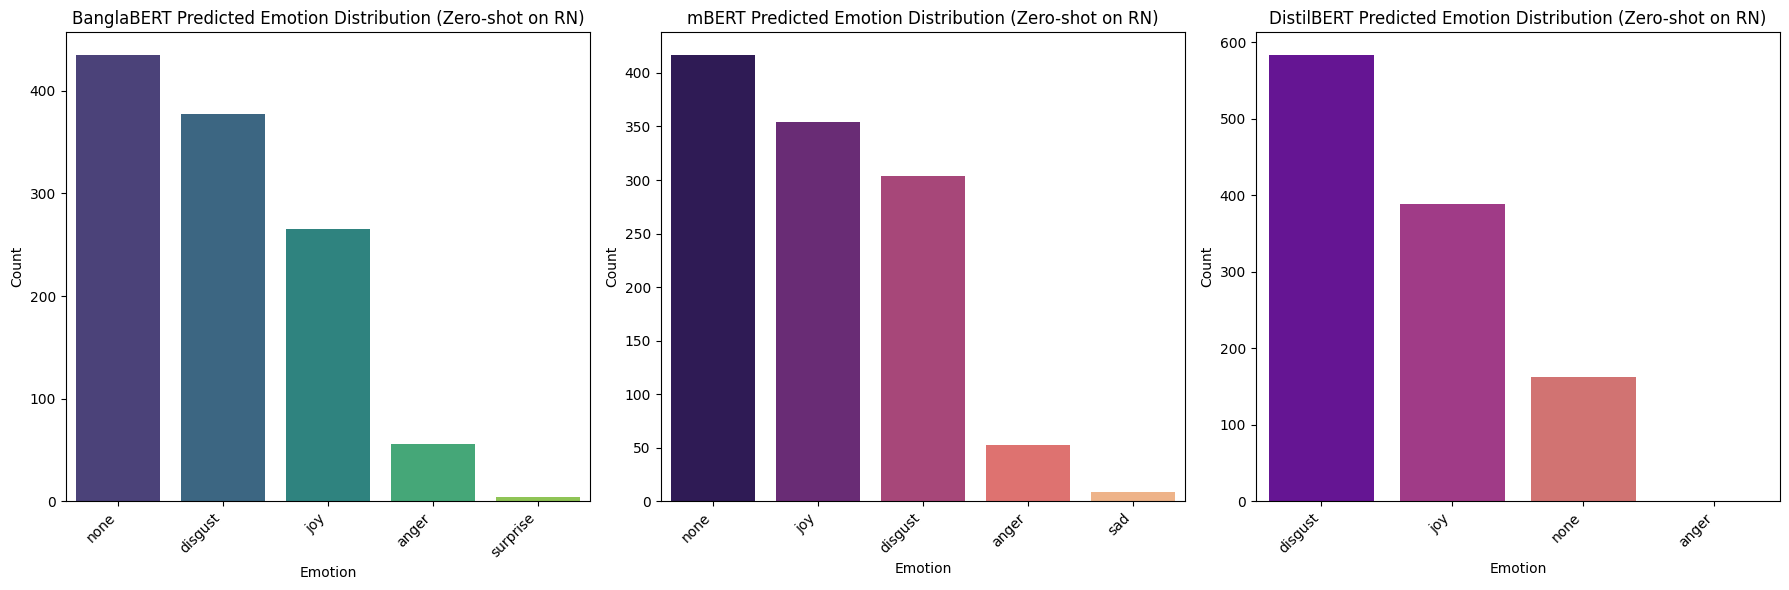

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.countplot(data=df_rn, x='banglabert_predicted_emotion', palette='viridis', order=df_rn['banglabert_predicted_emotion'].value_counts().index)
plt.title('BanglaBERT Predicted Emotion Distribution (Zero-shot on RN)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.countplot(data=df_rn, x='mbert_predicted_emotion', palette='magma', order=df_rn['mbert_predicted_emotion'].value_counts().index)
plt.title('mBERT Predicted Emotion Distribution (Zero-shot on RN)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.countplot(data=df_rn, x='distilbert_predicted_emotion', palette='plasma', order=df_rn['distilbert_predicted_emotion'].value_counts().index)
plt.title('DistilBERT Predicted Emotion Distribution (Zero-shot on RN)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate Zero-shot Accuracy for BanglaBERT
accuracy_banglabert_rn = accuracy_score(df_rn['emotion'], df_rn['banglabert_predicted_emotion'])

# Calculate Zero-shot Accuracy for mBERT
accuracy_mbert_rn = accuracy_score(df_rn['emotion'], df_rn['mbert_predicted_emotion'])

# Calculate Zero-shot Accuracy for DistilBERT
accuracy_distilbert_rn = accuracy_score(df_rn['emotion'], df_rn['distilbert_predicted_emotion'])

print(f"Zero-shot Accuracy (BanglaBERT on RN): {accuracy_banglabert_rn:.4f}")
print(f"Zero-shot Accuracy (mBERT on RN): {accuracy_mbert_rn:.4f}")
print(f"Zero-shot Accuracy (DistilBERT on RN): {accuracy_distilbert_rn:.4f}")


Zero-shot Accuracy (BanglaBERT on RN): 0.5506
Zero-shot Accuracy (mBERT on RN): 0.4169
Zero-shot Accuracy (DistilBERT on RN): 0.3245


This calculation provides insight into how well each model generalizes to Romanized Bengali without direct training on that specific language variant, using the existing emotion labels for evaluation. We can also summarize these in a DataFrame for better comparison.

In [ ]:
import pandas as pd

# Create a DataFrame to compare the zero-shot accuracies
zero_shot_accuracies_rn = pd.DataFrame({
    'Model': ['BanglaBERT', 'mBERT', 'DistilBERT'],
    'Zero-shot Accuracy (RN)': [accuracy_banglabert_rn, accuracy_mbert_rn, accuracy_distilbert_rn]
})

# Sort by accuracy for better readability
zero_shot_accuracies_rn = zero_shot_accuracies_rn.sort_values(by='Zero-shot Accuracy (RN)', ascending=False).reset_index(drop=True)

print("\n--- Zero-shot Accuracy Comparison on Romanized Bengali (RN) ---")
display(zero_shot_accuracies_rn)



--- Zero-shot Accuracy Comparison on Romanized Bengali (RN) ---


,Model,Zero-shot Accuracy (RN)
0,BanglaBERT,0.550572
1,mBERT,0.416887
2,DistilBERT,0.324538


### Zero-shot Emotion Classification on Romanized Bengali (RN) Data - *Without Transliteration*

We will now perform zero-shot classification directly on the Romanized Bengali (RN) text (`df_rn['text']`) using each model, without prior transliteration to native Bengali script. This will highlight how well the models inherently handle cross-script generalization.

In [ ]:
# Ensure models and tokenizers are in evaluation mode and on the correct device
banglabert_model.eval()
mbert_model.eval()
distilbert_model.eval()

# BanglaBERT Predictions (Direct on RN text)
banglabert_predictions_rn_direct = []
with torch.no_grad():
    for text_rn in tqdm(df_rn['text'], desc="BanglaBERT Zero-shot Prediction (Direct RN)"):
        inputs = banglabert_tokenizer(
            text_rn,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = banglabert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        banglabert_predictions_rn_direct.append(idx_to_label[preds])
df_rn['banglabert_predicted_emotion_direct'] = banglabert_predictions_rn_direct

# mBERT Predictions (Direct on RN text)
mbert_predictions_rn_direct = []
with torch.no_grad():
    for text_rn in tqdm(df_rn['text'], desc="mBERT Zero-shot Prediction (Direct RN)"):
        inputs = mbert_tokenizer(
            text_rn,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = mbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        mbert_predictions_rn_direct.append(idx_to_label[preds])
df_rn['mbert_predicted_emotion_direct'] = mbert_predictions_rn_direct

# DistilBERT Predictions (Direct on RN text)
distilbert_predictions_rn_direct = []
with torch.no_grad():
    for text_rn in tqdm(df_rn['text'], desc="DistilBERT Zero-shot Prediction (Direct RN)"):
        inputs = distilbert_tokenizer(
            text_rn,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = distilbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        distilbert_predictions_rn_direct.append(idx_to_label[preds])
df_rn['distilbert_predicted_emotion_direct'] = distilbert_predictions_rn_direct

print("\nSample of Direct Zero-shot predictions on original RN data:")
display(df_rn[['text', 'emotion', 'banglabert_predicted_emotion_direct', 'mbert_predicted_emotion_direct', 'distilbert_predicted_emotion_direct']].head())


BanglaBERT Zero-shot Prediction (Direct RN):   0%|          | 0/1137 [00:00<?, ?it/s]

mBERT Zero-shot Prediction (Direct RN):   0%|          | 0/1137 [00:00<?, ?it/s]

DistilBERT Zero-shot Prediction (Direct RN):   0%|          | 0/1137 [00:00<?, ?it/s]


Sample of Direct Zero-shot predictions on original RN data:


,text,emotion,banglabert_predicted_emotion_direct,mbert_predicted_emotion_direct,distilbert_predicted_emotion_direct
5,Osadharon chaliye jao,joy,disgust,anger,none
6,Shakil Ahmed otai to asol moza,none,disgust,disgust,joy
10,Ore moja paisi,joy,disgust,disgust,joy
15,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,sad,none,none,disgust
19,ei video te 1m view howa uchit,none,none,disgust,none


In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Calculate Zero-shot Accuracy for BanglaBERT (Direct RN)
accuracy_banglabert_rn_direct = accuracy_score(df_rn['emotion'], df_rn['banglabert_predicted_emotion_direct'])

# Calculate Zero-shot Accuracy for mBERT (Direct RN)
accuracy_mbert_rn_direct = accuracy_score(df_rn['emotion'], df_rn['mbert_predicted_emotion_direct'])

# Calculate Zero-shot Accuracy for DistilBERT (Direct RN)
accuracy_distilbert_rn_direct = accuracy_score(df_rn['emotion'], df_rn['distilbert_predicted_emotion_direct'])

print(f"Zero-shot Accuracy (BanglaBERT on Direct RN): {accuracy_banglabert_rn_direct:.4f}")
print(f"Zero-shot Accuracy (mBERT on Direct RN): {accuracy_mbert_rn_direct:.4f}")
print(f"Zero-shot Accuracy (DistilBERT on Direct RN): {accuracy_distilbert_rn_direct:.4f}")

# Create a DataFrame to compare the zero-shot accuracies (direct)
zero_shot_accuracies_rn_direct = pd.DataFrame({
    'Model': ['BanglaBERT', 'mBERT', 'DistilBERT'],
    'Zero-shot Accuracy (Direct RN)': [
        accuracy_banglabert_rn_direct,
        accuracy_mbert_rn_direct,
        accuracy_distilbert_rn_direct
    ]
})

# Sort by accuracy for better readability
zero_shot_accuracies_rn_direct = zero_shot_accuracies_rn_direct.sort_values(by='Zero-shot Accuracy (Direct RN)', ascending=False).reset_index(drop=True)

print("\n--- Zero-shot Accuracy Comparison on Direct Romanized Bengali (RN) ---")
display(zero_shot_accuracies_rn_direct)


Zero-shot Accuracy (BanglaBERT on Direct RN): 0.5453
Zero-shot Accuracy (mBERT on Direct RN): 0.2480
Zero-shot Accuracy (DistilBERT on Direct RN): 0.3201

--- Zero-shot Accuracy Comparison on Direct Romanized Bengali (RN) ---


,Model,Zero-shot Accuracy (Direct RN)
0,BanglaBERT,0.545295
1,DistilBERT,0.320141
2,mBERT,0.248021


In [ ]:
#BN tained eval on RN direct and RN-BN translation
#Now train on EN, eval on RN direct and RN-BN-EN translation

### Training Models Exclusively on English (EN) Data

We will now prepare a dataset containing only English (`lan == 'EN'`) texts for training and validation. Each of the three models (BanglaBERT, mBERT, DistilBERT) will be fine-tuned separately on this English data. After training, their performance will be evaluated on the Romanized Bengali (RN) dataset, both in its original Romanized form and its transliterated Bengali form.

In [21]:
# Filter the DataFrame for English (EN) data only
df_en = df[df['lan'] == 'EN'].copy()

print(f"Shape of English DataFrame: {df_en.shape}")
display(df_en.head())


Shape of English DataFrame: (747, 3)


,text,emotion,lan
0,Hands down. You are good. I mean smart good.,joy,EN
1,Your are very good. keep it up,none,EN
2,Man!! I will never get used to these videos of...,surprise,EN
7,"Man, you're brilliant!",surprise,EN
9,Tumi koto study r research kore amder hasaccho...,joy,EN


---

#### BanglaBERT Training and Evaluation on EN Data

In [25]:
from torch.utils.data import Dataset, DataLoader, random_split

# Tokenize the 'text' column using banglabert_tokenizer
tokenized_data_banglabert_en = banglabert_tokenizer(
    list(df_en['text'].values),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

# Convert emotion labels to numerical IDs
labels_banglabert_en = torch.tensor([label_to_idx[emotion] for emotion in df_en['emotion'].values])

# Adding the EmotionDataset class definition here to ensure it's available
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx].clone().detach()
        return item

    def __len__(self):
        return len(self.labels)

# Create the dataset
banglabert_en_dataset = EmotionDataset(tokenized_data_banglabert_en, labels_banglabert_en)

# Split into train/validation
train_size_banglabert_en = int(0.8 * len(banglabert_en_dataset))
val_size_banglabert_en = len(banglabert_en_dataset) - train_size_banglabert_en

train_dataset_banglabert_en, val_dataset_banglabert_en = random_split(
banglabert_en_dataset, [train_size_banglabert_en, val_size_banglabert_en]
)

batch_size = 16 # Defining batch_size here
train_dataloader_banglabert_en = DataLoader(train_dataset_banglabert_en, batch_size=batch_size, shuffle=True)
val_dataloader_banglabert_en = DataLoader(val_dataset_banglabert_en, batch_size=batch_size, shuffle=False)

print(f"BanglaBERT EN Training samples: {len(train_dataset_banglabert_en)}")
print(f"BanglaBERT EN Validation samples: {len(val_dataset_banglabert_en)}")

BanglaBERT EN Training samples: 597
BanglaBERT EN Validation samples: 150


In [28]:
import torch.nn as nn
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score
from transformers import get_linear_schedule_with_warmup

# Reset model for training on EN data
banglabert_model = AutoModelForSequenceClassification.from_pretrained(banglabert_model_name, num_labels=num_labels).to(device)

loss_fn_banglabert_en = nn.CrossEntropyLoss(weight=weights_tensor.to(device))
optimizer_banglabert_en = torch.optim.AdamW(banglabert_model.parameters(), lr=2e-5)
epochs = 5 # Defining epochs here
total_steps_banglabert_en = len(train_dataloader_banglabert_en) * epochs
scheduler_banglabert_en = get_linear_schedule_with_warmup(optimizer_banglabert_en, num_warmup_steps=0, num_training_steps=total_steps_banglabert_en)

# Training Loop for BanglaBERT on EN
banglabert_model.zero_grad()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs} (BanglaBERT on EN)")
    banglabert_model.train()
    total_train_loss_banglabert_en = 0

    for batch in tqdm(train_dataloader_banglabert_en, desc="BanglaBERT EN Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = banglabert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss_banglabert_en += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(banglabert_model.parameters(), 1.0)
        optimizer_banglabert_en.step()
        scheduler_banglabert_en.step()
        banglabert_model.zero_grad()

    avg_train_loss_banglabert_en = total_train_loss_banglabert_en / len(train_dataloader_banglabert_en)
    print(f"  BanglaBERT EN Average training loss: {avg_train_loss_banglabert_en:.4f}")

    banglabert_model.eval()
    predictions_banglabert_en = []
    true_labels_banglabert_en = []

    for batch in tqdm(val_dataloader_banglabert_en, desc="BanglaBERT EN Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = banglabert_model(input_ids, attention_mask=attention_mask, labels=labels)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).flatten()

        predictions_banglabert_en.extend(preds.cpu().numpy())
        true_labels_banglabert_en.extend(labels.cpu().numpy())

    eval_accuracy_banglabert_en = accuracy_score(true_labels_banglabert_en, predictions_banglabert_en)
    print(f"  BanglaBERT EN Validation Accuracy: {eval_accuracy_banglabert_en:.4f}")

print("\nBanglaBERT EN Training complete!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5 (BanglaBERT on EN)


BanglaBERT EN Training:   0%|          | 0/38 [00:00<?, ?it/s]

  BanglaBERT EN Average training loss: 1.7697


...

  BanglaBERT EN Validation Accuracy: 0.5800

Epoch 5/5 (BanglaBERT on EN)


BanglaBERT EN Training:   0%|          | 0/38 [00:00<?, ?it/s]

  BanglaBERT EN Average training loss: 1.0089


BanglaBERT EN Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

  BanglaBERT EN Validation Accuracy: 0.5800

BanglaBERT EN Training complete!


#### mBERT Training and Evaluation on EN Data

In [29]:
# Tokenize the 'text' column using mbert_tokenizer
tokenized_data_mbert_en = mbert_tokenizer(
    list(df_en['text'].values),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

# Convert emotion labels to numerical IDs
labels_mbert_en = torch.tensor([label_to_idx[emotion] for emotion in df_en['emotion'].values])

# Create the dataset
mbert_en_dataset = EmotionDataset(tokenized_data_mbert_en, labels_mbert_en)

# Split into train/validation
train_size_mbert_en = int(0.8 * len(mbert_en_dataset))
val_size_mbert_en = len(mbert_en_dataset) - train_size_mbert_en

train_dataset_mbert_en, val_dataset_mbert_en = random_split(
mbert_en_dataset, [train_size_mbert_en, val_size_mbert_en]
)

train_dataloader_mbert_en = DataLoader(train_dataset_mbert_en, batch_size=batch_size, shuffle=True)
val_dataloader_mbert_en = DataLoader(val_dataset_mbert_en, batch_size=batch_size, shuffle=False)

print(f"mBERT EN Training samples: {len(train_dataset_mbert_en)}")
print(f"mBERT EN Validation samples: {len(val_dataset_mbert_en)}")


mBERT EN Training samples: 597
mBERT EN Validation samples: 150


In [31]:
import torch
import gc # Import garbage collector

torch.cuda.empty_cache()

# Explicitly delete the previous model instance to free up GPU memory
if 'mbert_model' in locals() and mbert_model is not None:
    del mbert_model
    gc.collect() # Force garbage collection
    torch.cuda.empty_cache() # Clear cache again after deletion

# Reset model for training on EN data
mbert_model = AutoModelForSequenceClassification.from_pretrained(mbert_model_name, num_labels=num_labels).to(device)

loss_fn_mbert_en = nn.CrossEntropyLoss(weight=weights_tensor.to(device))
optimizer_mbert_en = torch.optim.AdamW(mbert_model.parameters(), lr=2e-5)
total_steps_mbert_en = len(train_dataloader_mbert_en) * epochs
scheduler_mbert_en = get_linear_schedule_with_warmup(optimizer_mbert_en, num_warmup_steps=0, num_training_steps=total_steps_mbert_en)

# Training Loop for mBERT on EN
mbert_model.zero_grad()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs} (mBERT on EN)")
    mbert_model.train()
    total_train_loss_mbert_en = 0

    for batch in tqdm(train_dataloader_mbert_en, desc="mBERT EN Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = mbert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss_mbert_en += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(mbert_model.parameters(), 1.0)
        optimizer_mbert_en.step()
        scheduler_mbert_en.step()
        mbert_model.zero_grad()

    avg_train_loss_mbert_en = total_train_loss_mbert_en / len(train_dataloader_mbert_en)
    print(f"  mBERT EN Average training loss: {avg_train_loss_mbert_en:.4f}")

    mbert_model.eval()
    predictions_mbert_en = []
    true_labels_mbert_en = []

    for batch in tqdm(val_dataloader_mbert_en, desc="mBERT EN Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = mbert_model(input_ids, attention_mask=attention_mask, labels=labels)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).flatten()

        predictions_mbert_en.extend(preds.cpu().numpy())
        true_labels_mbert_en.extend(labels.cpu().numpy())

    eval_accuracy_mbert_en = accuracy_score(true_labels_mbert_en, predictions_mbert_en)
    print(f"  mBERT EN Validation Accuracy: {eval_accuracy_mbert_en:.4f}")

print("\nmBERT EN Training complete!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5 (mBERT on EN)


mBERT EN Training:   0%|          | 0/38 [00:00<?, ?it/s]

  mBERT EN Average training loss: 1.5583


...

  mBERT EN Validation Accuracy: 0.5333

Epoch 5/5 (mBERT on EN)


mBERT EN Training:   0%|          | 0/38 [00:00<?, ?it/s]

  mBERT EN Average training loss: 0.6890


mBERT EN Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

  mBERT EN Validation Accuracy: 0.5333

mBERT EN Training complete!


#### DistilBERT Training and Evaluation on EN Data

In [32]:
# Tokenize the 'text' column using distilbert_tokenizer
tokenized_data_distilbert_en = distilbert_tokenizer(
    list(df_en['text'].values),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

# Convert emotion labels to numerical IDs
labels_distilbert_en = torch.tensor([label_to_idx[emotion] for emotion in df_en['emotion'].values])

# Create the dataset
distilbert_en_dataset = EmotionDataset(tokenized_data_distilbert_en, labels_distilbert_en)

# Split into train/validation
train_size_distilbert_en = int(0.8 * len(distilbert_en_dataset))
val_size_distilbert_en = len(distilbert_en_dataset) - train_size_distilbert_en

train_dataset_distilbert_en, val_dataset_distilbert_en = random_split(
distilbert_en_dataset, [train_size_distilbert_en, val_size_distilbert_en]
)

train_dataloader_distilbert_en = DataLoader(train_dataset_distilbert_en, batch_size=batch_size, shuffle=True)
val_dataloader_distilbert_en = DataLoader(val_dataset_distilbert_en, batch_size=batch_size, shuffle=False)

print(f"DistilBERT EN Training samples: {len(train_dataset_distilbert_en)}")
print(f"DistilBERT EN Validation samples: {len(val_dataset_distilbert_en)}")


DistilBERT EN Training samples: 597
DistilBERT EN Validation samples: 150


In [33]:
# Reset model for training on EN data
distilbert_model = AutoModelForSequenceClassification.from_pretrained(distilbert_model_name, num_labels=num_labels).to(device)

loss_fn_distilbert_en = nn.CrossEntropyLoss(weight=weights_tensor.to(device))
optimizer_distilbert_en = torch.optim.AdamW(distilbert_model.parameters(), lr=2e-5)
total_steps_distilbert_en = len(train_dataloader_distilbert_en) * epochs
scheduler_distilbert_en = get_linear_schedule_with_warmup(optimizer_distilbert_en, num_warmup_steps=0, num_training_steps=total_steps_distilbert_en)

# Training Loop for DistilBERT on EN
distilbert_model.zero_grad()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs} (DistilBERT on EN)")
    distilbert_model.train()
    total_train_loss_distilbert_en = 0

    for batch in tqdm(train_dataloader_distilbert_en, desc="DistilBERT EN Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = distilbert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss_distilbert_en += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(distilbert_model.parameters(), 1.0)
        optimizer_distilbert_en.step()
        scheduler_distilbert_en.step()
        distilbert_model.zero_grad()

    avg_train_loss_distilbert_en = total_train_loss_distilbert_en / len(train_dataloader_distilbert_en)
    print(f"  DistilBERT EN Average training loss: {avg_train_loss_distilbert_en:.4f}")

    distilbert_model.eval()
    predictions_distilbert_en = []
    true_labels_distilbert_en = []

    for batch in tqdm(val_dataloader_distilbert_en, desc="DistilBERT EN Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = distilbert_model(input_ids, attention_mask=attention_mask, labels=labels)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).flatten()

        predictions_distilbert_en.extend(preds.cpu().numpy())
        true_labels_distilbert_en.extend(labels.cpu().numpy())

    eval_accuracy_distilbert_en = accuracy_score(true_labels_distilbert_en, predictions_distilbert_en)
    print(f"  DistilBERT EN Validation Accuracy: {eval_accuracy_distilbert_en:.4f}")

print("\nDistilBERT EN Training complete!")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5 (DistilBERT on EN)


DistilBERT EN Training:   0%|          | 0/38 [00:00<?, ?it/s]

  DistilBERT EN Average training loss: 1.7039


...

  DistilBERT EN Validation Accuracy: 0.6333

Epoch 5/5 (DistilBERT on EN)


DistilBERT EN Training:   0%|          | 0/38 [00:00<?, ?it/s]

  DistilBERT EN Average training loss: 0.8663


DistilBERT EN Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

  DistilBERT EN Validation Accuracy: 0.6400

DistilBERT EN Training complete!


### Zero-shot Evaluation on Romanized Bengali (RN) Data (from EN-trained models)

Now, we'll use the models that were just trained *exclusively on English data* to perform zero-shot predictions on the Romanized Bengali (RN) dataset. We will evaluate two scenarios:
1.  **Direct RN**: Predicting on the raw Romanized Bengali text.
2.  **RN to BN Transliterated**: Predicting on the Romanized Bengali text after it has been transliterated to native Bengali script (using the existing `translated_text` column in `df_rn`).

In [40]:
# Ensure df_rn and its 'translated_text' column are available
# If df_rn is not found or its 'translated_text' column is missing, re-create it.
if 'df_rn' not in locals() or not ('translated_text' in df_rn.columns):
    print("Warning: df_rn or 'translated_text' column not found. Attempting to re-create df_rn and perform transliteration.")
    # Re-create df_rn from global df (assuming 'df' is always available as per kernel state)
    df_rn = df[df['lan'] == 'RN'].copy()

    # Ensure tqdm.pandas is initialized, which is needed for .progress_apply
    from tqdm.notebook import tqdm
    tqdm.pandas(desc="Transliterating RN to BN")

    # Perform transliteration to populate 'translated_text' column
    # (assuming 'pipeline' is always available as per kernel state)
    df_rn['translated_text'] = df_rn['text'].progress_apply(pipeline.run_stage1_transliterate)

# Explicitly define label_to_idx, idx_to_label, and num_labels
# This ensures they are always available regardless of previous cell execution order.
# Assuming 'df' is loaded in an earlier cell and available globally.
class_labels = sorted(df['emotion'].unique())
label_to_idx = {label: i for i, label in enumerate(class_labels)}
idx_to_label = {i: label for i, label in enumerate(class_labels)}
num_labels = len(class_labels)

# --- BanglaBERT Zero-shot Predictions (trained on EN) ---
banglabert_model.eval()

# Scenario 1: Direct RN
banglabert_predictions_en_on_rn_direct = []
with torch.no_grad():
    for text_rn in tqdm(df_rn['text'], desc="BanglaBERT (EN-trained) on Direct RN"):
        inputs = banglabert_tokenizer(
            text_rn,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = banglabert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        banglabert_predictions_en_on_rn_direct.append(idx_to_label[preds])
df_rn['banglabert_predicted_emotion_en_on_rn_direct'] = banglabert_predictions_en_on_rn_direct

# Scenario 2: RN to BN Transliterated
banglabert_predictions_en_on_rn_trans = []
with torch.no_grad():
    for text_rn_trans in tqdm(df_rn['translated_text'], desc="BanglaBERT (EN-trained) on RN-BN Trans"):
        inputs = banglabert_tokenizer(
            text_rn_trans,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = banglabert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        banglabert_predictions_en_on_rn_trans.append(idx_to_label[preds])
df_rn['banglabert_predicted_emotion_en_on_rn_trans'] = banglabert_predictions_en_on_rn_trans

# --- mBERT Zero-shot Predictions (trained on EN) ---
mbert_model.eval()

# Scenario 1: Direct RN
mbert_predictions_en_on_rn_direct = []
with torch.no_grad():
    for text_rn in tqdm(df_rn['text'], desc="mBERT (EN-trained) on Direct RN"):
        inputs = mbert_tokenizer(
            text_rn,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = mbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        mbert_predictions_en_on_rn_direct.append(idx_to_label[preds])
df_rn['mbert_predicted_emotion_en_on_rn_direct'] = mbert_predictions_en_on_rn_direct

# Scenario 2: RN to BN Transliterated
mbert_predictions_en_on_rn_trans = []
with torch.no_grad():
    for text_rn_trans in tqdm(df_rn['translated_text'], desc="mBERT (EN-trained) on RN-BN Trans"):
        inputs = mbert_tokenizer(
            text_rn_trans,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = mbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        mbert_predictions_en_on_rn_trans.append(idx_to_label[preds])
df_rn['mbert_predicted_emotion_en_on_rn_trans'] = mbert_predictions_en_on_rn_trans

# --- DistilBERT Zero-shot Predictions (trained on EN) ---
distilbert_model.eval()

# Scenario 1: Direct RN
distilbert_predictions_en_on_rn_direct = []
with torch.no_grad():
    for text_rn in tqdm(df_rn['text'], desc="DistilBERT (EN-trained) on Direct RN"):
        inputs = distilbert_tokenizer(
            text_rn,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = distilbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        distilbert_predictions_en_on_rn_direct.append(idx_to_label[preds])
df_rn['distilbert_predicted_emotion_en_on_rn_direct'] = distilbert_predictions_en_on_rn_direct

# Scenario 2: RN to BN Transliterated
distilbert_predictions_en_on_rn_trans = []
with torch.no_grad():
    for text_rn_trans in tqdm(df_rn['translated_text'], desc="DistilBERT (EN-trained) on RN-BN Trans"):
        inputs = distilbert_tokenizer(
            text_rn_trans,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = distilbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        distilbert_predictions_en_on_rn_trans.append(idx_to_label[preds])
df_rn['distilbert_predicted_emotion_en_on_rn_trans'] = distilbert_predictions_en_on_rn_trans

print("\nSample of Zero-shot predictions from EN-trained models on RN data:")
display(df_rn[[
    'text', 'emotion',
    'banglabert_predicted_emotion_en_on_rn_direct',
    'banglabert_predicted_emotion_en_on_rn_trans',
    'mbert_predicted_emotion_en_on_rn_direct',
    'mbert_predicted_emotion_en_on_rn_trans',
    'distilbert_predicted_emotion_en_on_rn_direct',
    'distilbert_predicted_emotion_en_on_rn_trans'
]].head())

BanglaBERT (EN-trained) on Direct RN:   0%|          | 0/1137 [00:00<?, ?it/s]

BanglaBERT (EN-trained) on RN-BN Trans:   0%|          | 0/1137 [00:00<?, ?it/s]

mBERT (EN-trained) on Direct RN:   0%|          | 0/1137 [00:00<?, ?it/s]

mBERT (EN-trained) on RN-BN Trans:   0%|          | 0/1137 [00:00<?, ?it/s]

DistilBERT (EN-trained) on Direct RN:   0%|          | 0/1137 [00:00<?, ?it/s]

DistilBERT (EN-trained) on RN-BN Trans:   0%|          | 0/1137 [00:00<?, ?it/s]


Sample of Zero-shot predictions from EN-trained models on RN data:


,text,emotion,banglabert_predicted_emotion_en_on_rn_direct,banglabert_predicted_emotion_en_on_rn_trans,mbert_predicted_emotion_en_on_rn_direct,mbert_predicted_emotion_en_on_rn_trans,distilbert_predicted_emotion_en_on_rn_direct,distilbert_predicted_emotion_en_on_rn_trans
5,Osadharon chaliye jao,joy,none,joy,disgust,none,none,none
6,Shakil Ahmed otai to asol moza,none,none,none,none,none,none,none
10,Ore moja paisi,joy,joy,joy,joy,joy,joy,none
15,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,sad,none,none,none,none,joy,none
19,ei video te 1m view howa uchit,none,none,none,none,none,none,none


In [41]:
# Calculate Accuracies for EN-trained models on RN data

# BanglaBERT
accuracy_banglabert_en_on_rn_direct = accuracy_score(df_rn['emotion'], df_rn['banglabert_predicted_emotion_en_on_rn_direct'])
accuracy_banglabert_en_on_rn_trans = accuracy_score(df_rn['emotion'], df_rn['banglabert_predicted_emotion_en_on_rn_trans'])

# mBERT
accuracy_mbert_en_on_rn_direct = accuracy_score(df_rn['emotion'], df_rn['mbert_predicted_emotion_en_on_rn_direct'])
accuracy_mbert_en_on_rn_trans = accuracy_score(df_rn['emotion'], df_rn['mbert_predicted_emotion_en_on_rn_trans'])

# DistilBERT
accuracy_distilbert_en_on_rn_direct = accuracy_score(df_rn['emotion'], df_rn['distilbert_predicted_emotion_en_on_rn_direct'])
accuracy_distilbert_en_on_rn_trans = accuracy_score(df_rn['emotion'], df_rn['distilbert_predicted_emotion_en_on_rn_trans'])

print(f"BanglaBERT (EN-trained) Zero-shot Accuracy (Direct RN): {accuracy_banglabert_en_on_rn_direct:.4f}")
print(f"BanglaBERT (EN-trained) Zero-shot Accuracy (RN-BN Trans): {accuracy_banglabert_en_on_rn_trans:.4f}\n")

print(f"mBERT (EN-trained) Zero-shot Accuracy (Direct RN): {accuracy_mbert_en_on_rn_direct:.4f}")
print(f"mBERT (EN-trained) Zero-shot Accuracy (RN-BN Trans): {accuracy_mbert_en_on_rn_trans:.4f}\n")

print(f"DistilBERT (EN-trained) Zero-shot Accuracy (Direct RN): {accuracy_distilbert_en_on_rn_direct:.4f}")
print(f"DistilBERT (EN-trained) Zero-shot Accuracy (RN-BN Trans): {accuracy_distilbert_en_on_rn_trans:.4f}\n")

# Consolidate all accuracies into a single DataFrame for comparison
all_zero_shot_accuracies = pd.DataFrame({
    'Model': [
        'BanglaBERT (EN-trained)', 'BanglaBERT (EN-trained)',
        'mBERT (EN-trained)', 'mBERT (EN-trained)',
        'DistilBERT (EN-trained)', 'DistilBERT (EN-trained)'
    ],
    'Scenario': [
        'Direct RN',
        'RN-BN Transliterated',
        'Direct RN',
        'RN-BN Transliterated',
        'Direct RN',
        'RN-BN Transliterated'
    ],
    'Accuracy': [
        accuracy_banglabert_en_on_rn_direct,
        accuracy_banglabert_en_on_rn_trans,
        accuracy_mbert_en_on_rn_direct,
        accuracy_mbert_en_on_rn_trans,
        accuracy_distilbert_en_on_rn_direct,
        accuracy_distilbert_en_on_rn_trans
    ]
})

print("--- Summary of Zero-shot Accuracies (Models Trained on EN) ---")
display(all_zero_shot_accuracies.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


BanglaBERT (EN-trained) Zero-shot Accuracy (Direct RN): 0.5022
BanglaBERT (EN-trained) Zero-shot Accuracy (RN-BN Trans): 0.4362

mBERT (EN-trained) Zero-shot Accuracy (Direct RN): 0.4222
mBERT (EN-trained) Zero-shot Accuracy (RN-BN Trans): 0.3149

DistilBERT (EN-trained) Zero-shot Accuracy (Direct RN): 0.3694
DistilBERT (EN-trained) Zero-shot Accuracy (RN-BN Trans): 0.2832

--- Summary of Zero-shot Accuracies (Models Trained on EN) ---


,Model,Scenario,Accuracy
0,BanglaBERT (EN-trained),Direct RN,0.502199
1,BanglaBERT (EN-trained),RN-BN Transliterated,0.436236
2,mBERT (EN-trained),Direct RN,0.422164
3,DistilBERT (EN-trained),Direct RN,0.369393
4,mBERT (EN-trained),RN-BN Transliterated,0.314864
5,DistilBERT (EN-trained),RN-BN Transliterated,0.283201


This table provides a clear comparison of how each model, after being trained exclusively on English data, performs on Romanized Bengali, both directly and after transliteration.

### Zero-shot Evaluation on RN-BN-EN Translated Data (from EN-trained models)

This section performs a multi-step zero-shot evaluation:
1.  **RN to BN**: Uses the `translated_text` column in `df_rn` (from previous steps).
2.  **BN to EN Translation**: Translates the BN text to English.
3.  **EN-trained Emotion Models**: Uses the models previously trained only on English data to predict emotions on the EN translated text.

In [38]:
# Load Bengali to English Translation Model
bn_en_model_name = "Helsinki-NLP/opus-mt-bn-en"
bn_en_tokenizer = AutoTokenizer.from_pretrained(bn_en_model_name)
bn_en_model = AutoModelForSeq2SeqLM.from_pretrained(bn_en_model_name).to(device)

print(f"Loaded BN-to-EN translation model: {bn_en_model_name}")

def translate_bn_to_en(text: str) -> str:
    inputs = bn_en_tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    with torch.no_grad():
        generated_ids = bn_en_model.generate(**inputs, max_length=128, num_beams=5, early_stopping=True)
    translated_text = bn_en_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return translated_text

# Apply BN to EN translation to the 'translated_text' column (which is RN to BN)
# This creates the RN-BN-EN translated text
tqdm.pandas(desc="Translating BN to EN")
df_rn['translated_to_en_text'] = df_rn['translated_text'].progress_apply(translate_bn_to_en)

print("\nSample of RN original, RN-BN, and RN-BN-EN translated text:")
display(df_rn[['text', 'translated_text', 'translated_to_en_text']].head())


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/806k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.25M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Loaded BN-to-EN translation model: Helsinki-NLP/opus-mt-bn-en


Translating BN to EN:   0%|          | 0/1137 [00:00<?, ?it/s]


Sample of RN original, RN-BN, and RN-BN-EN translated text:


,text,translated_text,translated_to_en_text
5,Osadharon chaliye jao,অসাধারণ চালিয়ে যাও,Keep going.
6,Shakil Ahmed otai to asol moza,হাকিল আলহাম ঐটাই তো আসল যসা,Hagil Alham that's what's real
10,Ore moja paisi,ওরে মজা পাইছি,I got him.
15,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,ডিয়ার পুরাতন ব্রো নেক্সট ভিডিও'র জন্য আরো কত ...,How long do you want to wait for the old bro n...
19,ei video te 1m view howa uchit,এই ভিডিও তে ১ম ভিউ হওয়া উচিত,This video should be 1st View


In [42]:
# Perform zero-shot emotion classification on 'translated_to_en_text' using EN-trained models

# Ensure models are in evaluation mode
banglabert_model.eval()
mbert_model.eval()
distilbert_model.eval()

# BanglaBERT Predictions (EN-trained model on RN-BN-EN text)
banglabert_predictions_en_on_rn_bn_en = []
with torch.no_grad():
    for text_en in tqdm(df_rn['translated_to_en_text'], desc="BanglaBERT (EN-trained) on RN-BN-EN"):
        inputs = banglabert_tokenizer(
            text_en,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = banglabert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        banglabert_predictions_en_on_rn_bn_en.append(idx_to_label[preds])
df_rn['banglabert_predicted_emotion_en_on_rn_bn_en'] = banglabert_predictions_en_on_rn_bn_en

# mBERT Predictions (EN-trained model on RN-BN-EN text)
mbert_predictions_en_on_rn_bn_en = []
with torch.no_grad():
    for text_en in tqdm(df_rn['translated_to_en_text'], desc="mBERT (EN-trained) on RN-BN-EN"):
        inputs = mbert_tokenizer(
            text_en,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = mbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        mbert_predictions_en_on_rn_bn_en.append(idx_to_label[preds])
df_rn['mbert_predicted_emotion_en_on_rn_bn_en'] = mbert_predictions_en_on_rn_bn_en

# DistilBERT Predictions (EN-trained model on RN-BN-EN text)
distilbert_predictions_en_on_rn_bn_en = []
with torch.no_grad():
    for text_en in tqdm(df_rn['translated_to_en_text'], desc="DistilBERT (EN-trained) on RN-BN-EN"):
        inputs = distilbert_tokenizer(
            text_en,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        outputs = distilbert_model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).item()
        distilbert_predictions_en_on_rn_bn_en.append(idx_to_label[preds])
df_rn['distilbert_predicted_emotion_en_on_rn_bn_en'] = distilbert_predictions_en_on_rn_bn_en

print("\nSample of Zero-shot predictions from EN-trained models on RN-BN-EN data:")
display(df_rn[[
    'text', 'emotion', 'translated_to_en_text',
    'banglabert_predicted_emotion_en_on_rn_bn_en',
    'mbert_predicted_emotion_en_on_rn_bn_en',
    'distilbert_predicted_emotion_en_on_rn_bn_en'
]].head())


BanglaBERT (EN-trained) on RN-BN-EN:   0%|          | 0/1137 [00:00<?, ?it/s]

mBERT (EN-trained) on RN-BN-EN:   0%|          | 0/1137 [00:00<?, ?it/s]

DistilBERT (EN-trained) on RN-BN-EN:   0%|          | 0/1137 [00:00<?, ?it/s]


Sample of Zero-shot predictions from EN-trained models on RN-BN-EN data:


,text,emotion,translated_to_en_text,banglabert_predicted_emotion_en_on_rn_bn_en,mbert_predicted_emotion_en_on_rn_bn_en,distilbert_predicted_emotion_en_on_rn_bn_en
5,Osadharon chaliye jao,joy,Keep going.,none,joy,joy
6,Shakil Ahmed otai to asol moza,none,Hagil Alham that's what's real,none,none,none
10,Ore moja paisi,joy,I got him.,none,none,none
15,Dear Rahat Bro Next Video'r Jnno Aro Koto Din ...,sad,How long do you want to wait for the old bro n...,none,disgust,none
19,ei video te 1m view howa uchit,none,This video should be 1st View,none,none,none


In [43]:
# Calculate Accuracies for EN-trained models on RN-BN-EN data

accuracy_banglabert_en_on_rn_bn_en = accuracy_score(df_rn['emotion'], df_rn['banglabert_predicted_emotion_en_on_rn_bn_en'])
accuracy_mbert_en_on_rn_bn_en = accuracy_score(df_rn['emotion'], df_rn['mbert_predicted_emotion_en_on_rn_bn_en'])
accuracy_distilbert_en_on_rn_bn_en = accuracy_score(df_rn['emotion'], df_rn['distilbert_predicted_emotion_en_on_rn_bn_en'])

print(f"BanglaBERT (EN-trained) Zero-shot Accuracy (RN-BN-EN): {accuracy_banglabert_en_on_rn_bn_en:.4f}")
print(f"mBERT (EN-trained) Zero-shot Accuracy (RN-BN-EN): {accuracy_mbert_en_on_rn_bn_en:.4f}")
print(f"DistilBERT (EN-trained) Zero-shot Accuracy (RN-BN-EN): {accuracy_distilbert_en_on_rn_bn_en:.4f}")

# Update the comparison DataFrame with these new accuracies
all_zero_shot_accuracies_updated = pd.concat([
    all_zero_shot_accuracies,
    pd.DataFrame({
        'Model': [
            'BanglaBERT (EN-trained)',
            'mBERT (EN-trained)',
            'DistilBERT (EN-trained)'
        ],
        'Scenario': [
            'RN-BN-EN Translated',
            'RN-BN-EN Translated',
            'RN-BN-EN Translated'
        ],
        'Accuracy': [
            accuracy_banglabert_en_on_rn_bn_en,
            accuracy_mbert_en_on_rn_bn_en,
            accuracy_distilbert_en_on_rn_bn_en
        ]
    })
], ignore_index=True)

print("\n--- Updated Summary of Zero-shot Accuracies (Models Trained on EN) ---")
display(all_zero_shot_accuracies_updated.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


BanglaBERT (EN-trained) Zero-shot Accuracy (RN-BN-EN): 0.4204
mBERT (EN-trained) Zero-shot Accuracy (RN-BN-EN): 0.4116
DistilBERT (EN-trained) Zero-shot Accuracy (RN-BN-EN): 0.4415

--- Updated Summary of Zero-shot Accuracies (Models Trained on EN) ---


,Model,Scenario,Accuracy
0,BanglaBERT (EN-trained),Direct RN,0.502199
1,DistilBERT (EN-trained),RN-BN-EN Translated,0.441513
2,BanglaBERT (EN-trained),RN-BN Transliterated,0.436236
3,mBERT (EN-trained),Direct RN,0.422164
4,BanglaBERT (EN-trained),RN-BN-EN Translated,0.420405
5,mBERT (EN-trained),RN-BN-EN Translated,0.411609
6,DistilBERT (EN-trained),Direct RN,0.369393
7,mBERT (EN-trained),RN-BN Transliterated,0.314864
8,DistilBERT (EN-trained),RN-BN Transliterated,0.283201


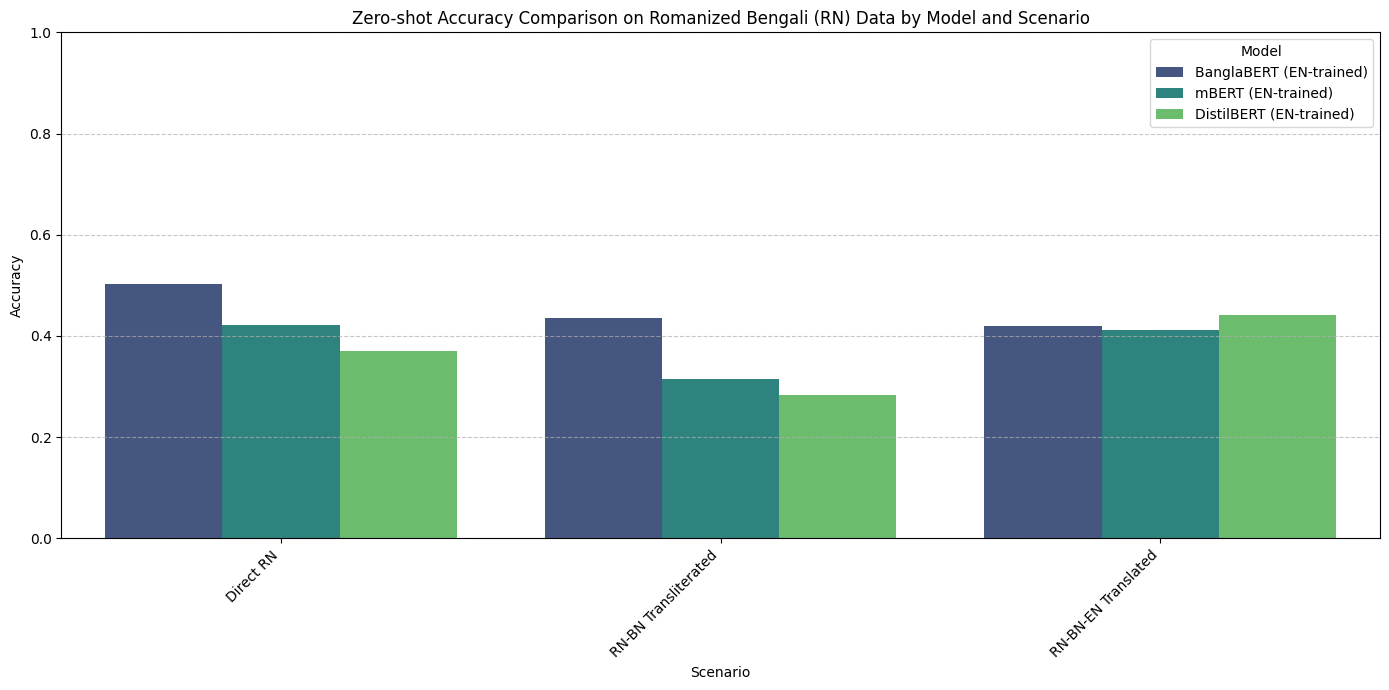

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(data=all_zero_shot_accuracies_updated, x='Scenario', y='Accuracy', hue='Model', palette='viridis')
plt.title('Zero-shot Accuracy Comparison on Romanized Bengali (RN) Data by Model and Scenario')
plt.xlabel('Scenario')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()